원샘플 티테스트

In [1]:
# 통계흐름

# 데이터 확인
# 시각화와 같은 방법으로 분포 확인
# - 크게 이상없으면진행
# - 이상치 있으면 제거
# - 너무 편향이 심하면 로그변환 또는 비모수 검정 진행
# (약간치우친 정도는 괜찮고, 이상치없으면 괜찮음, 표본개수 20개 이상이면 괜찮음)
# 평균 계산
# 표준오차(se)
# 신뢰구간 확인
# t-test
# 효과크기(effect size)확인

In [2]:
# 가정 >>> 사용자 체류시간의 평균은 5분이다.

import numpy as np
import pandas as pd

# 사용자 체류시간 (분)
df = pd.DataFrame({
    "session_time": [5.5, 6.2, 4.8, 5.9, 6.5, 5.1, 5.8, 6.0, 5.7, 6.3,
                     5.4, 6.1, 5.6, 5.9, 6.2, 5.3, 5.8, 6.4, 6.0, 5.7]
})

In [3]:
df

,session_time
0,5.5
1,6.2
2,4.8
3,5.9
4,6.5
5,5.1
6,5.8
7,6.0
8,5.7
9,6.3


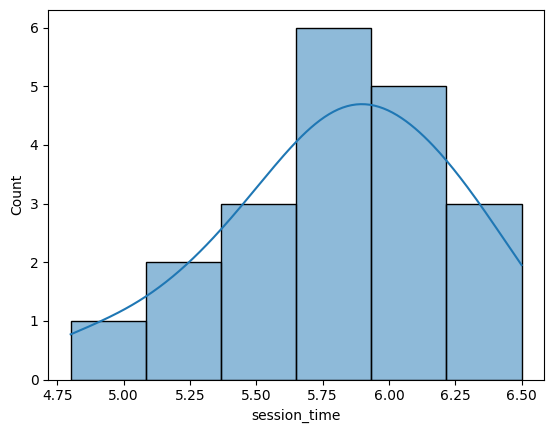

In [12]:
# 시각화_히스토그램

import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['session_time'], kde = True)
plt.show()

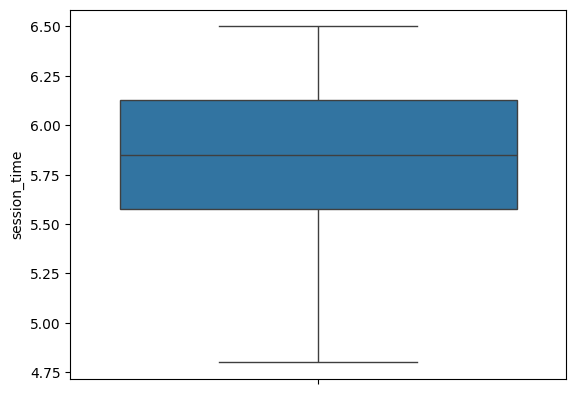

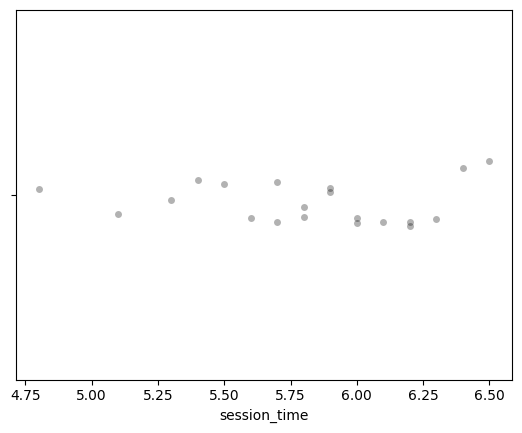

In [25]:
# 시각화_박스플롯

import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(df['session_time'], showfliers = True)
plt.show()

# 실무에서는 점도 같이 봄. 실제 데이터가 어떻게 생겼는지 바로 보임
# 데이터의 밀집정도, 이상치 명확 확인가능
sns.stripplot(x=df['session_time'], color='black', alpha=0.3)
plt.show()

In [4]:
# 기본 통계확인
# 주로 std, min, max가장 많이 확인

df.describe()

# 현재 데이터에서 std가 0.43이고 mean이 5.8
# std / mean = 0.08%정도 나옴
# 0.1 ~ 0.3 → 보통 정도로 해석
# 그럼 평균대비 약 8%정도 흔들린다고 해석해야함. 데이터가 비교적 몰려있음

,session_time
count,20.000000
mean,5.810000
std,0.438778
min,4.800000
25%,5.575000
50%,5.850000
75%,6.125000
max,6.500000


In [5]:
# SE및 STD구하기
# 실제 se를 구하려면 std값 / 표본개수로 구하지만
# 패키지를 사용하면 자동으로 값 구하기 가능

from statsmodels.stats.weightstats import DescrStatsW

desc = DescrStatsW(df['session_time'])

print(f'SE(표준오차) : {desc.std_mean}')
print(f'Std(표준편차) : {desc.std}') # 데이터가 대략 0.4정도 흔들림
print(f'데이터(포본)개수 : {desc.nobs}')
print(f'mean : {desc.mean}')


# 기초통계값 해석 법
# 단순 se가 0.098이 나왔다고 해서 이것만 보고 안정적인지 아닌지 판단불가
# 보통 평균대비 비율을 가장많이 확인함 >>> SE / mean
# 또는 신뢰구간(CI)를 확인

print()

print(f'평균대비 비율 : {desc.std_mean / desc.mean}') # 0.016으로 약 1.7%정도 흔들림
# 평균대비 1~2% 흔들리는 경우 꽤 안정적이라고 판단

SE(표준오차) : 0.09811379000667382
Std(표준편차) : 0.42766809560686203
데이터(포본)개수 : 20.0
mean : 5.8100000000000005

평균대비 비율 : 0.016887055078601346


In [6]:
# 신뢰구간(CI) : 진짜 평균이 있을 것 같은 범위

# 신뢰구간 확인 이유
# 평균을 하나만 뽑지만 표본이기때문에 실제 모평균을 알 수 없음
# '때문에 이 범위 안에 있을 확률이 높다' 라는 구간을 구하는것

# 신뢰구간 95% 공식 >>> 평균 ± 1.96 × SE
# 신뢰구간 99% 공식 >>> 평균 ± 2.58 × SE

In [7]:
from statsmodels.stats.weightstats import DescrStatsW

desc = DescrStatsW(df['session_time'])

# 아무것도 설정안하면 신뢰구간 95%로 설정
# 99%로 바꾸고싶다면 desc.tconfint_mean(alpha=0.01)로 지정
ci_low, ci_hight = desc.tconfint_mean()

print(ci_low, ci_hight)
# 실제 사용시간의 평균(모평균)은 5.6 ~ 6.0사이에 있을것이라고 확인가능

5.604645477446871 6.01535452255313


In [8]:
# one-sample-t-test
# 우리의 평균이 특정 값(기준값)과 다른가?
# 하나의 집단 vs 기준값

# 가정 >>> 평균 체류시간이 5분인가?

In [9]:
from scipy import stats

# popmean : 비교 기준이 되는 모집단 평균값(가설값)
# 때문에 popmean을 넣지 않으면 작동불가
# 이 데이터 평균이 어떤 값이랑 다른지 확인하는 과정이기때문
t_test, pvalue = stats.ttest_1samp(df['session_time'], popmean = 5)

print(f't값 : {t_test}')
print(f'p-value : {pvalue}')
# 0.05보다 p값이 더 작음 >>>평균이 5라는 가정 하에서는 이런 데이터가 나올 확률이 거의 없음
# 귀무가설(평균은 5분이다) 기각

# t값 = (표본평균 - popmean) / se
# t값 = 기준값 대비 얼마나 멀리 떨어졌는지 (표준화된 거리)
# 평균이 기준값(5)에서 se기준으로 8배나 멀리 떨어져있다는 뜻

# 사실 실무에서 t값자체를 해석하는 일은 거의 없음
# 단지 p-value를 만드는 중간 계산값일 뿐임
# t값은 0보다 크면 평균이 기준보다 크다는 뜻이고 0보다 작으면 평균이 기준보다 작다는 뜻임
# 또 t값이 +8이라면 기준값인 5보다 크다는것이고 -8이면 기준값인 5보다 작다는 뜻
# 방향이 중요한 이유는 기준값 5분이 아닌데 -면 더 작을 수도 있다는거고 +면 더 클 수도 있다는것임
# -로 나오면 5분은 아니지만 3분 이런식일 수 있음

#p-value는 ‘차이 있음’만 말해주고
# t값의 부호는 기준값보다 큰지 작은지 방향을 알려준다

t값 : 8.255720219807056
p-value : 1.0469757851631606e-07


In [35]:
# 효과크기(effect size)
# 차이가 얼마나 큰지 수치로 표현하는 것
# p-value는 단순 차이가 있는지 없는지만 판단하고
# effect size는 얼마나 큰지 확인함

# 원샘플 티테스트에서는 주로 Cohens'd방법을 사용
# (표본평균 - 기준값) / 표준편차(std)

mean = df['session_time'].mean()
std = df['session_time'].std()

print(f'd 값 : {(mean - 5)/std:.2f}') # 1.8로 큰 효과를 보임
# 평균이 기준값보다 약 1.8 표준편차만큼 떨어져 있다

# d값 해석
# d = 0.1 → 거의 차이 없음
# d = 0.5 → 체감 가능
# d = 1.2 → 엄청 큰 차이

d 값 : 1.85


원샘플 티테스트 비모수 검정

In [ ]:
# 비모수 검정
# 심하게 치우쳐있음
# 이상치 많음
# 표본 적음

In [37]:
import pandas as pd

w_df = pd.DataFrame({
    "session_time": [
        1, 2, 2, 3, 3, 2, 1, 2, 3,   # 대부분 낮은 값
        50, 60, 70
    ]
})

In [38]:
w_df

,session_time
0,1
1,2
2,2
3,3
4,3
5,2
6,1
7,2
8,3
9,50


In [60]:
w_df.median()

,0
session_time,2.5


<Axes: xlabel='session_time', ylabel='Count'>

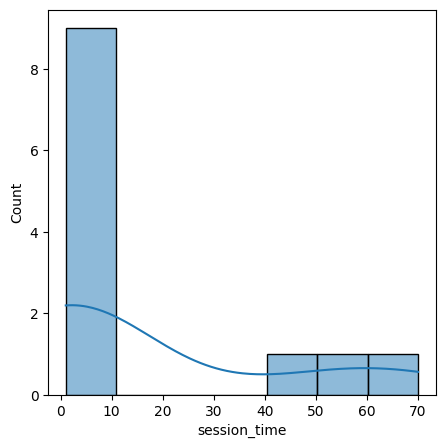

In [43]:
# 시각화 확인_ 히스토그램

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (5,5))
sns.histplot(w_df['session_time'], kde=True)

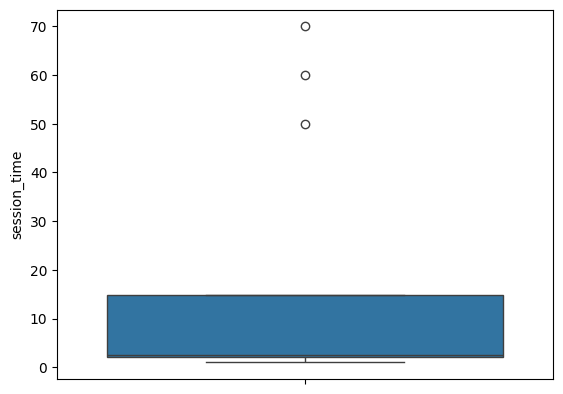

<Axes: xlabel='session_time'>

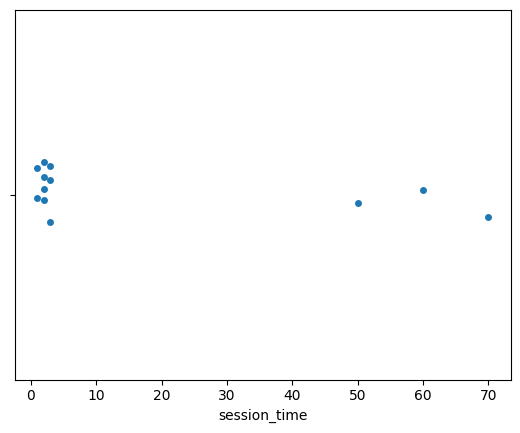

In [47]:
# 시각화 박스플롯

sns.boxplot(w_df['session_time'])
plt.show()

sns.stripplot(x = w_df['session_time'])

# 시각화 확인했더니 이상치 존재 및 극단값으로 몰려있음

In [57]:
# 그냥 t-test진행 시

from scipy import stats

t,p = stats.ttest_1samp(w_df['session_time'],popmean = 5)

print(t,p)

# 이상치 때문에 평균 커짐(평균16.5)
# 결과 왜곡 가능성있음
# p값 0.05보다 큼

print(w_df.mean())

1.5122101376900656 0.15866586197202442
session_time    16.583333
dtype: float64


In [59]:
#비모수 검정

# Wilcoxon은 “기준 대비 방향”을 보기 때문에 반드시 기준값을 빼줘야 함
# 원래 값	변환 후
# 6	+1
# 5	0
# 4	-1
# 차이값 절대값 정렬 (rank) -> 부호(+/-) 확인 -> 전체적으로 +가 많은지 -가 많은지 판단

t_stats, p_value = stats.wilcoxon(df['session_time'] - 5)

print(t_stats)
print(p_value)

# 비모수 검정은 중앙값을 확인함
# 중앙값 2.5이고 기준값이 5였기때문에
# 중앙값은 기준값보다 낮아 보이지만, 통계적으로 유의한 차이는 확인되지 않은것

33.0
0.64892578125


In [ ]:
# 비모수 검정에서는 std, se값 굳이 확인하지 않음
# 대신 분포의 형태, 중앙값, 순위기반 결과 확인

# t-test(모수)의 경우에는 평균에 기반했기때문에
# 표준편차, 표준오차가 중요해서 얼마나 퍼져있냐가 핵심이었지만

# 비모수 검정에서는 순위기반이고 중앙값중심
# 때문에 순서만 중요하고 퍼진정도는 덜 중요